# Recap

**Table of contents**<a id='toc0_'></a>    
- 1. [Setup](#toc1_)    
- 2. [Types and operators](#toc2_)    
- 3. [Containers, slicing and broadcasting](#toc3_)    
- 4. [Views vs. copies](#toc4_)    
- 5. [Conditionals and loops](#toc5_)    
- 6. [Functions and classes](#toc6_)    
- 7. [Optimizers and root-finders](#toc7_)    
  - 7.1. [The problem](#toc7_1_)    
  - 7.2. [Grid search](#toc7_2_)    
  - 7.3. [Your own optimizer: gradient descent](#toc7_3_)    
  - 7.4. [Your own root-finder: Newton and bisection](#toc7_4_)    
  - 7.5. [Calling scipy](#toc7_5_)    
- 8. [Random numbers](#toc8_)    
- 9. [Data: load, summarize and visualize](#toc9_)    
  - 9.1. [DataFrames](#toc9_1_)    
  - 9.2. [Long vs. wide, concat, merge and groupby](#toc9_2_)    
  - 9.3. [Printing](#toc9_3_)    
  - 9.4. [Plotting](#toc9_4_)    
  - 9.5. [Save and load](#toc9_5_)    
- 10. [Solving and simulating a model](#toc10_)    
- 11. [Structure, testing, debugging and Git](#toc11_)    
- 12. [Before you hand in](#toc12_)    
- 13. [Where to look it up](#toc13_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

This notebook is a **recap of the whole course**, organized as the [learning checklist](../CHECKLIST.md).

For each item you get the short version, the shortest possible example, and a pointer to the lecture.

## 1. <a id='toc1_'></a>[Setup](#toc0_)

In [1]:
import os
from copy import deepcopy
from types import SimpleNamespace
import pickle

import numpy as np
import pandas as pd
from scipy import optimize

from IPython.display import display # shows a DataFrame as a table

import matplotlib.pyplot as plt
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'-'})
plt.rcParams.update({'font.size':14})

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

## 2. <a id='toc2_'></a>[Types and operators](#toc0_)

*Lecture 2.*

* `int`, `float`, `str`, `bool` - check with `type()`, convert with `int()`, `float()`, `str()`.
* Arithmetic `+ - * / // % **`, comparison `== != < >=`, logic `and or not`, augmentation `+=`.
* A `float` is a **binary approximation** of a decimal number. Never compare two floats with `==`.

**Print one thing per line**, and use `f'{x = }'`, which prints *both the expression and its value*. Then you never have to guess which number is which.

In [2]:
x = 3
print(f'{type(x) = }')
y = 2.0
print(f'{type(y) = }')
name = 'GDP'
print(f'{type(name) = }')
ok = True
print(f'{type(ok) = }')

type(x) = <class 'int'>
type(y) = <class 'float'>
type(name) = <class 'str'>
type(ok) = <class 'bool'>


In [3]:
print(f'{x/2 = }') # / always returns a float
print(f'{x//2 = }')
print(f'{x%2 = }')
print(f'{x**2 = }')

x/2 = 1.5
x//2 = 1
x%2 = 1
x**2 = 9


In [5]:
print(f'{int('7')+1 = }')
print(f'{str(7)+'1' = }')
print(f'{float(True) = }')

int('7')+1 = 8
str(7)+'1' = '71'
float(True) = 1.0


In [5]:
y += 1 # same as y = y + 1
print(f'{y = }')
print(f'{x < 3 or ok = }')
print(f'{not ok = }')

y = 3.0
x < 3 or ok = True
not ok = False


In [6]:
print(f'{0.1+0.2 == 0.3 = }')          # False - the two numbers differ in the 17th digit
print(f'{np.isclose(0.1+0.2,0.3) = }') # this is the check to use

0.1+0.2 == 0.3 = False
np.isclose(0.1+0.2,0.3) = np.True_


## 3. <a id='toc3_'></a>[Containers, slicing and broadcasting](#toc0_)

*Lecture 2-3.*

| | mutable | good at |
| --- | --- | --- |
| list `[1,2,3]` | yes | an ordered collection that grows and can hold anything |
| tuple `(1,2,3)` | **no** | a fixed record you do not want changed by accident |
| dict `{'a':1}` | yes | look-up by name |
| array `np.array([1,2,3])` | yes | math on many numbers at once |

Indexing is **0-based**, `[a:b]` includes `a` but excludes `b`, `-1` is the last element, and `[a:b:step]` skips.

In [7]:
xs = [4,5,6,7,8]
print(f'{xs[0] = }')
print(f'{xs[-1] = }')
print(f'{xs[1:3] = }')
print(f'{xs[::2] = }')
print(f'{len(xs) = }')

xs[0] = 4
xs[-1] = 8
xs[1:3] = [5, 6]
xs[::2] = [4, 6, 8]
len(xs) = 5


In [8]:
par = {'alpha':0.3,'delta':0.1}
print(f'{par["alpha"] = }')
print(f'{list(par.keys()) = }')
print(f'{list(par.values()) = }')

par["alpha"] = 0.3
list(par.keys()) = ['alpha', 'delta']
list(par.values()) = [0.3, 0.1]


In [9]:
A = np.arange(6).reshape(2,3)
print(f'{A = }')
print(f'{A.shape = }')
print(f'{A.dtype = }')

A = array([[0, 1, 2],
       [3, 4, 5]])
A.shape = (2, 3)
A.dtype = dtype('int64')


In [10]:
print(f'{A.sum(axis=0) = }') # reduce along an axis
print(f'{A.sum(axis=1) = }')
print(f'{A.argmin() = }')
print(f'{A[A>3] = }')        # boolean mask
print(f'{A[:,[0,2]] = }')    # index list

A.sum(axis=0) = array([3, 5, 7])
A.sum(axis=1) = array([ 3, 12])
A.argmin() = np.int64(0)
A[A>3] = array([4, 5])
A[:,[0,2]] = array([[0, 2],
       [3, 5]])


**Broadcasting.** Arrays of different shape are stretched to a common shape. This is how a function is evaluated on a grid without a single loop.

In [11]:
k = np.linspace(1,10,5)     # shape (5,)
s = np.array([0.1,0.2,0.3]) # shape (3,)

Y = s[:,np.newaxis]*k[np.newaxis,:]**0.3 # shape (3,5): one row per savings rate

print(f'{Y.shape = }')
print(f'{Y.round(3) = }')

Y.shape = (3, 5)
Y.round(3) = array([[0.1  , 0.142, 0.167, 0.185, 0.2  ],
       [0.2  , 0.285, 0.334, 0.37 , 0.399],
       [0.3  , 0.427, 0.5  , 0.555, 0.599]])


In [12]:
B = np.ones((3,2))
print(f'{A@B = }')              # matrix product: (2,3)@(3,2) -> (2,2)
print(f'{A*np.ones((2,3)) = }') # element-by-element - a completely different operation

A@B = array([[ 3.,  3.],
       [12., 12.]])
A*np.ones((2,3)) = array([[0., 1., 2.],
       [3., 4., 5.]])


## 4. <a id='toc4_'></a>[Views vs. copies](#toc0_)

*Lecture 2-3.* **The most common source of silent bugs.**

* `b = a` does not create anything new: two names, one object.
* Lists: `a.copy()` copies the outer list only, `deepcopy(a)` copies all the way down.
* numpy: a **slice is a view** (shares memory), while a **boolean mask or an index list gives a copy**.

In [13]:
a = [1,2,3]; b = a; b[0] = 99
print(f'reference: {a = }')

a = [1,2,3]; b = a.copy(); b[0] = 99
print(f'copy:      {a = }')

a = [[1,2],[3,4]]; b = a.copy(); b[0][0] = 99
print(f'shallow:   {a = }') # the inner lists are still shared!

a = [[1,2],[3,4]]; b = deepcopy(a); b[0][0] = 99
print(f'deep:      {a = }')

reference: a = [99, 2, 3]
copy:      a = [1, 2, 3]
shallow:   a = [[99, 2], [3, 4]]
deep:      a = [[1, 2], [3, 4]]


In [8]:
x = np.arange(5)
v = x[:2]; v[:] = 99    # a slice is a VIEW
print(f'after view: {x = }')

x = np.arange(5)
c = x[[0,1]]; c[:] = 99 # an index list gives a COPY
print(f'after copy: {x = }')

after view: x = array([99, 99,  2,  3,  4])
after copy: x = array([0, 1, 2, 3, 4])


## 5. <a id='toc5_'></a>[Conditionals and loops](#toc0_)

*Lecture 2.*

* `if` / `elif` / `else`. For non-booleans: `0`, `''`, `[]`, `{}` and `None` are `False`, everything else is `True`.
* `for` when you know what to loop over, `while` when you only know when to stop.
* `enumerate` gives the index, `zip` runs two lists in parallel, `continue` skips one iteration, `break` leaves the loop.
* **A recursion over time must be a loop.** Everything else should be vectorized.

In [9]:
ks = [0.5,1.0,2.0,-1.0]
names = ['low','medium','high','nonsense']

for i,(k,name) in enumerate(zip(ks,names)):

    if k < 0: continue # skip the nonsense

    if k < 1: kind = 'below'
    elif k == 1: kind = 'at'
    else: kind = 'above'

    print(f'{i}: {name:>6s}, k = {k:.1f}, {kind} 1')

0:    low, k = 0.5, below 1
1: medium, k = 1.0, at 1
2:   high, k = 2.0, above 1


In [10]:
# a recursion cannot be vectorized - it has to be a loop
k = 0.1
for t in range(1000):
    k_next = 0.2*k**0.3+0.9*k
    if np.isclose(k_next,k): break # converged
    k = k_next

print(f'{k = :.4f}') # the steady state
print(f'{t = }')     # periods it took

k = 2.6914
t = 126


## 6. <a id='toc6_'></a>[Functions and classes](#toc0_)

*Lecture 2-3.*

* A function can take several inputs and return several outputs, and arguments can have default values.
* **Scope:** what happens in a function stays in the function. It can *read* the globals - and that is exactly the danger.
* A function is an **object**: it can be stored in a variable and passed to another function.
* A class collects parameters (**attributes**) and equations (**methods**) in one object. `self` is the object itself.

In [17]:
def utility(c,l,alpha=0.5):
    """ utility of consumption and leisure

    Args:

        c (float): consumption
        l (float): leisure
        alpha (float,optional): weight on consumption

    Returns:

        (float): utility

    """

    return alpha*np.log(c)+(1-alpha)*np.log(l)

print(f'{utility(1.0,2.0) = :.4f}')
print(f'{utility(1.0,2.0,alpha=0.8) = :.4f}')

utility(1.0,2.0) = 0.3466
utility(1.0,2.0,alpha=0.8) = 0.1386


In [18]:
alpha = 0.5
def bad(c,l):
    return alpha*np.log(c)+(1-alpha)*np.log(l) # alpha is taken from the outside

alpha = 0.9 # ... and changed somewhere else, 200 lines later

print(f'{bad(1.0,2.0) = :.4f}')     # same call ...
print(f'{utility(1.0,2.0) = :.4f}') # ... different answer

bad(1.0,2.0) = 0.0693
utility(1.0,2.0) = 0.3466


In [19]:
def apply_to_grid(f,grid):
    """ apply the function f to each element of grid """

    return np.array([f(x) for x in grid])

grid = np.array([1.0,4.0,9.0])
print(f'{apply_to_grid(np.sqrt,grid) = }')
print(f'{apply_to_grid(lambda x: x**2,grid) = }')

apply_to_grid(np.sqrt,grid) = array([1., 2., 3.])
apply_to_grid(lambda x: x**2,grid) = array([ 1., 16., 81.])


In [20]:
class ConsumerClass:

    def __init__(self,alpha=0.5,I=10.0): # called when the object is created
        self.alpha = alpha
        self.I = I
        self.sol = SimpleNamespace()

    def __str__(self): # called by print()
        return f'consumer with alpha = {self.alpha:.2f} and I = {self.I:.1f}'

    def demand(self,p1,p2):
        """ Cobb-Douglas demand """

        return self.alpha*self.I/p1, (1-self.alpha)*self.I/p2

for alpha_ in [0.25,0.75]:
    con = ConsumerClass(alpha=alpha_) # each instance carries its own parameters
    print(con)
    print(f'{con.demand(1.0,2.0) = }')

consumer with alpha = 0.25 and I = 10.0
con.demand(1.0,2.0) = (2.5, 3.75)
consumer with alpha = 0.75 and I = 10.0
con.demand(1.0,2.0) = (7.5, 1.25)


## 7. <a id='toc7_'></a>[Optimizers and root-finders](#toc0_)

*Lecture 5.*

* **Grid search** always works and is easy to check, but the accuracy is limited by the distance between the grid points.
* Every solver is **a loop with two stopping rules**: a tolerance (close enough) and a maximum number of iterations (give up).
* **Gradient descent** only needs a slope, and steps against it. **Newton** needs a derivative and a starting point. **Bisection** needs a bracket $[a,b]$ where the function changes sign - and then it cannot fail.
* Write the algorithm down **in words** before you write the code, and **return whether it converged**.

### 7.1. <a id='toc7_1_'></a>[The problem](#toc0_)

Everything below solves **the same problem**, so the methods can be compared. A consumer with income $I$ buys two goods at prices $p_1$ and $p_2$:

$$ \max_{x_1,x_2\ \geq\ 0}\; u(x_1,x_2) = \alpha\ln x_1+(1-\alpha)\ln x_2 \qquad \text{s.t.} \qquad p_1x_1+p_2x_2 \leq I $$

**Two steps of thinking before any code:**

1. **The budget binds.** More is better, so all income is spent and $x_2$ follows from $x_1$,

$$ x_2(x_1) = \frac{I-p_1x_1}{p_2} $$

   Two variables become one, and the constraint disappears.

2. **Maximizing is minimizing.** Every solver in `scipy.optimize` *minimizes*, so we always work with the **objective**

$$ f(x_1) = -u\big(x_1,x_2(x_1)\big) $$

An **optimizer** looks for the minimum of $f$. A **root-finder** looks for a root of the first order condition, $f'(x_1) = 0$. Same problem, two ways in.

Here we know the answer, $x_1^{\ast} = \alpha I/p_1$ - which is the only reason to use a problem this simple.

In [21]:
alpha,I,p1,p2 = 0.5,10.0,1.0,2.0

def x2_of_x1(x1):
    """ the budget constraint binds """

    return (I-p1*x1)/p2

def obj(x1):
    """ the objective: minus utility along the budget line """

    return -(alpha*np.log(x1)+(1-alpha)*np.log(x2_of_x1(x1)))

def dobj(x1,h=1e-6):
    """ the derivative of the objective, by a central difference """

    return (obj(x1+h)-obj(x1-h))/(2*h)

x1_true = alpha*I/p1
print(f'{x1_true = :.8f}')

x1_true = 5.00000000


### 7.2. <a id='toc7_2_'></a>[Grid search](#toc0_)

Put a grid on $x_1$, evaluate the objective in every point, keep the best one:

$$ \min_{x_1 \in X_1} f(x_1), \qquad X_1 = \left\{0,\ldots,\frac{I}{p_1}\right\} $$

Nothing clever happens - and that is the point. It cannot fail, but the accuracy is what pays for it.

In [22]:
x1_grid = np.linspace(1e-8,I/p1-1e-8,500)
f_grid = obj(x1_grid) # plain arithmetic, so the whole grid goes through at once

i = np.argmin(f_grid)
x1_gridsearch = x1_grid[i]

print(f'{x1_gridsearch = :.4f}')
print(f'{x1_true = :.4f}')
print(f'{x1_grid[1]-x1_grid[0] = :.4f}') # the accuracy cannot be better than the spacing

x1_gridsearch = 4.9900
x1_true = 5.0000
x1_grid[1]-x1_grid[0] = 0.0200


### 7.3. <a id='toc7_3_'></a>[Your own optimizer: gradient descent](#toc0_)

A grid search *looks everywhere*. An optimizer *follows the slope*: it looks at the ground under its feet and steps downhill.

**Algorithm:** `gradient_descent(f,df,x0,gamma,tol,maxit)`

1. Choose a starting point $x_0$, a step size $\gamma > 0$, a tolerance $\epsilon$ and a maximum number of iterations.
2. Compute the derivative $f'(x_k)$.
3. If $|f'(x_k)| < \epsilon$: **stop**, the ground is flat.
4. Otherwise step downhill, $x_{k+1} = x_k - \gamma f'(x_k)$.
5. Go back to 2 - unless $k$ has reached the maximum, then **stop** and report failure.

The step is *against* the slope: where the objective is rising the derivative is positive and we move left, and the other way around. Steps are long where the objective is steep and short where it flattens out, so the algorithm slows down exactly when it gets close.

In [23]:
def gradient_descent(f,df,x0,gamma=0.5,tol=1e-8,maxit=10_000):
    """ minimize f by stepping against the derivative

    Args:

        f (callable): objective, takes a float and returns a float
        df (callable): derivative of the objective
        x0 (float): starting point
        gamma (float): step size
        tol (float): stop when the derivative is smaller than this
        maxit (int): maximum number of iterations

    Returns:

        (float): the point where the algorithm stopped
        (bool): whether it converged
        (int): iterations used

    """

    x = x0
    for it in range(maxit):

        dfx = df(x)
        if abs(dfx) < tol:
            return x,True,it # stopping rule 1: tolerance

        x -= gamma*dfx # step downhill

    return x,False,it # stopping rule 2: too many iterations

x1_gd,converged,it = gradient_descent(obj,dobj,x0=1.0,gamma=0.5)

print(f'{x1_gd = :.8f}')
print(f'{converged = }')
print(f'{it = }')

x1_gd = 4.99999975
converged = True
it = 805


**The step size is ours to choose, and it decides whether the optimizer works at all.** Too small and it takes forever, too large and it overshoots - here right out of the budget set, where $x_2 < 0$, the logarithm is undefined and everything becomes `nan`.

In [24]:
for gamma in [0.05,0.5,5.0,20.0]:
    x1_now,converged_now,it_now = gradient_descent(obj,dobj,x0=1.0,gamma=gamma)
    print(f'{gamma = :5.2f}: {x1_now = :9.6f}, {converged_now = }, {it_now = }')

gamma =  0.05: x1_now =  5.000000, converged_now = True, it_now = 8125
gamma =  0.50: x1_now =  5.000000, converged_now = True, it_now = 805
gamma =  5.00: x1_now =  5.000000, converged_now = True, it_now = 72


gamma = 20.00: x1_now =       nan, converged_now = False, it_now = 9999


C:\Users\gmf123\AppData\Local\Temp\ipykernel_3692\3280146971.py:11: RuntimeWarning: invalid value encountered in log
  return -(alpha*np.log(x1)+(1-alpha)*np.log(x2_of_x1(x1)))


### 7.4. <a id='toc7_4_'></a>[Your own root-finder: Newton and bisection](#toc0_)

The first order condition is an equation, so the same optimum can be found by solving

$$ g(x_1) = f'(x_1) = 0 $$

**Algorithm:** `newton(g,x0,tol,maxit)`

1. Choose a starting point $x_0$, a tolerance $\epsilon$ and a maximum number of iterations.
2. If $|g(x_k)| < \epsilon$: **stop**, we are at a root.
3. Otherwise replace $g$ by its tangent in $x_k$ and jump to where the tangent crosses zero, $x_{k+1} = x_k - g(x_k)/g'(x_k)$.
4. Go back to 2 - unless $k$ has reached the maximum, then **stop** and report failure.

Newton is **fast** - the number of correct digits roughly doubles per iteration - but it needs a derivative and a starting point, and it is thrown off by a flat spot where $g'(x_k)\approx0$.

In [25]:
def newton(g,x0,tol=1e-8,maxit=100,h=1e-6):
    """ Newton's method with a numerical derivative

    Args:

        g (callable): function we want a root of
        x0 (float): starting point
        tol (float): stop when |g(x)| is smaller than this
        maxit (int): maximum number of iterations
        h (float): step size in the numerical derivative

    Returns:

        (float): the root
        (bool): whether the algorithm converged

    """

    x = x0
    for it in range(maxit):

        gx = g(x)
        if abs(gx) < tol:
            return x,True # stopping rule 1: tolerance

        dgx = (g(x+h)-g(x-h))/(2*h) # central numerical derivative
        x -= gx/dgx

    return x,False # stopping rule 2: too many iterations

x1_newton,converged = newton(dobj,x0=1.0) # a root of the first order condition

print(f'{x1_newton = :.8f}')
print(f'{converged = }')

x1_newton = 4.99999998
converged = True


**Algorithm:** `bisect(g,a,b,tol,maxit)`

1. Start from a bracket $[a,b]$ where $g(a)$ and $g(b)$ have **opposite signs**. A continuous function must then cross zero in between.
2. Take the midpoint $m = (a+b)/2$.
3. If $(b-a)/2 < \epsilon$: **stop**, the bracket is small enough.
4. Otherwise keep the half where the sign still changes: if $g(a)g(m) \leq 0$ set $b=m$, and otherwise $a=m$.
5. Go back to 2 - unless $k$ has reached the maximum, then **stop** and report failure.

Bisection is **slow** - the bracket only halves, so each extra digit costs about three more iterations - but within the bracket it cannot fail. Newton is the opposite: fast when it works, and no promises when it does not.

In [26]:
def bisect(g,a,b,tol=1e-8,maxit=500):
    """ bisection; requires g(a) and g(b) to have opposite signs """

    assert g(a)*g(b) < 0, 'no sign change in the bracket'

    for it in range(maxit):

        m = (a+b)/2
        if (b-a)/2 < tol: return m,True # stopping rule 1: tolerance

        if g(a)*g(m) <= 0: b = m # the sign changes in the left half
        else: a = m              # ... so it must be in the right half

    return m,False # stopping rule 2: too many iterations

x1_bisect,converged = bisect(dobj,1e-4,I/p1-1e-4)

print(f'{x1_bisect = :.8f}')
print(f'{converged = }')

x1_bisect = 4.99999999
converged = True


### 7.5. <a id='toc7_5_'></a>[Calling scipy](#toc0_)

* `optimize.minimize_scalar` hands your function a **number**, `optimize.minimize` hands it an **array**.
* `Nelder-Mead` uses no derivatives (robust, slow), `BFGS` is unconstrained, `L-BFGS-B` takes bounds, `SLSQP` takes constraints.
* Parameters go to the objective with `args=(...)` or through a `lambda`.
* A constraint can be **substituted away**, **re-parameterized**, or handed to a solver that accepts constraints.

**Write down which problem you are handing the solver.** The same economics can be posed in more than one way, and the way you pose it decides which method you may use:

$$ \text{1.}\quad \min_{0\,\leq\, x_1\, \leq\, I/p_1} \; f(x_1) \qquad\qquad
   \text{2.}\quad \min_{x_1,x_2\ \geq\ 0} \; -u(x_1,x_2) \quad \text{s.t.} \quad I-p_1x_1-p_2x_2 \geq 0 $$

The first has substituted the budget away and left a **bound**, which `minimize_scalar` handles. The second keeps a genuine **constraint**, which needs `SLSQP`.

In [27]:
# 1. one variable, constraint substituted away
res = optimize.minimize_scalar(obj,bounds=(1e-8,I/p1-1e-8),method='bounded')
x1_scipy = res.x

print(f'{x1_scipy = :.8f}')
print(f'{res.success = }')

x1_scipy = 5.00000000
res.success = True


In [28]:
# 2. two variables, constraint given to the solver (x is an ARRAY)
obj_2d = lambda x,alpha: -(alpha*np.log(x[0])+(1-alpha)*np.log(x[1]))
constraints = ({'type':'ineq','fun': lambda x: I-p1*x[0]-p2*x[1]},)
bounds = ((1e-8,None),(1e-8,None))

res = optimize.minimize(obj_2d,x0=[1.0,1.0],args=(alpha,),method='SLSQP',
                        bounds=bounds,constraints=constraints)

print(f'{res.x.round(6) = }')
print(f'{res.success = }')
print(f'{I-p1*res.x[0]-p2*res.x[1] = :.2e}') # check the constraint yourself

res.x.round(6) = array([4.999974, 2.500013])
res.success = True
I-p1*res.x[0]-p2*res.x[1] = 8.88e-16


**Root-finding in scipy.** One equation, $g(x) = 0$ with $x \in \mathbb{R}$, or a system, $g(x) = 0$ with $x \in \mathbb{R}^n$.

In [29]:
# one equation: the first order condition again
res = optimize.root_scalar(dobj,bracket=[1e-4,I/p1-1e-4],method='brentq')
print(f'{res.root = :.8f}')

res.root = 5.00000000


In [30]:
# a system: x is an array and the output is a list of equations, one per unknown
def eqs(x):
    return [x[0]+x[1]-3, x[0]-x[1]-1]

res = optimize.root(eqs,[0,0])
print(f'{res.x = }')
print(f'{res.success = }')

res.x = array([2., 1.])
res.success = True


**The same problem, five ways.** The grid search is by far the most expensive and by far the least accurate - the others all use the derivative, or a bracket, instead of trying everything.

In [31]:
solutions = {'grid search':x1_gridsearch,'gradient descent':x1_gd,'newton':x1_newton,
             'bisection':x1_bisect,'scipy: minimize_scalar':x1_scipy}

print(f'{"method":>22s} {"x1":>12s} {"error":>10s}')
for name,x1_now in solutions.items():
    print(f'{name:>22s} {x1_now:12.8f} {np.abs(x1_now-x1_true):10.1e}')

                method           x1      error
           grid search   4.98997996    1.0e-02
      gradient descent   4.99999975    2.5e-07
                newton   4.99999998    1.7e-08
             bisection   4.99999999    9.3e-09
scipy: minimize_scalar   5.00000000    8.9e-16


**`success = True` is not a proof.** A function can have several optima and several roots, and the starting point or the bracket decides which one you find. Check the constraints, compare methods, and always try several starting points.

In [32]:
g = lambda x: np.sin(x[0])+0.05*x[0]**2

for x0 in [-6.0,0.0,6.0]:
    res = optimize.minimize(g,[x0],method='BFGS')
    print(f'{x0 = :5.1f} -> {res.x[0] = :7.3f}, {res.fun = :6.3f}, {res.success = }')

x0 =  -6.0 -> res.x[0] =  -7.069, res.fun =  1.791, res.success = True


x0 =   0.0 -> res.x[0] =  -1.428, res.fun = -0.888, res.success = True
x0 =   6.0 -> res.x[0] =   4.271, res.fun =  0.008, res.success = True


## 8. <a id='toc8_'></a>[Random numbers](#toc0_)

*Lecture 6.*

* `rng = np.random.default_rng(seed)` gives a generator. Same seed - same numbers, always. Its **state** moves forward each time you draw.
* Use **several generators** when different parts of the model should not disturb each other.
* **Monte Carlo:** an expectation is just an average over draws. The error falls with $1/\sqrt{N}$ - four times as many draws halves it.

In [33]:
rng = np.random.default_rng(1917)
print(f'{rng.normal(size=3) = }')
print(f'{rng.normal(size=3) = }') # the state has moved on

rng = np.random.default_rng(1917)
print(f'{rng.normal(size=3) = }') # ... but a new generator with the same seed repeats it

rng.normal(size=3) = array([ 0.15427361, -0.39422272, -0.1813755 ])
rng.normal(size=3) = array([-0.61572017, -1.02907207, -0.77156317])
rng.normal(size=3) = array([ 0.15427361, -0.39422272, -0.1813755 ])


In [34]:
print(f'{rng.uniform(size=2) = }')
print(f'{rng.choice([0,1],size=5) = }')
print(f'{rng.normal(loc=1.0,scale=0.5,size=2) = }')

rng.uniform(size=2) = array([0.15906079, 0.67902922])
rng.choice([0,1],size=5) = array([0, 1, 0, 1, 1])
rng.normal(loc=1.0,scale=0.5,size=2) = array([0.53014923, 0.41316092])


In [35]:
rng = np.random.default_rng(1917)
for N in [10**2,10**4,10**6]:
    x = rng.normal(size=N)
    print(f'N = {N:8d}: E[x^2] = {np.mean(x**2):.4f} (true = 1.0000)')

N =      100: E[x^2] = 0.7512 (true = 1.0000)


N =    10000: E[x^2] = 1.0123 (true = 1.0000)


N =  1000000: E[x^2] = 0.9979 (true = 1.0000)


## 9. <a id='toc9_'></a>[Data: load, summarize and visualize](#toc0_)

*Lecture 4 and 7-8.*

### 9.1. <a id='toc9_1_'></a>[DataFrames](#toc0_)

In a notebook, **`display()` shows a DataFrame as a table** while `print()` only gives you text. Use `display` whenever you look at data.

First look at a new data set: `.head()` for the first rows, `.info()` for the types and the number of non-missing values, and `.describe()` for the distribution of each variable.

In [36]:
df = pd.DataFrame({
    'municipality':['Copenhagen','Aarhus','Odense','Copenhagen','Aarhus','Odense'],
    'year':[2020,2020,2020,2021,2021,2021],
    'employment':[0.78,0.74,0.71,0.80,0.75,0.72],
    'income':[340.,300.,285.,355.,310.,290.]})

display(df.head(3))

,municipality,year,employment,income
0,Copenhagen,2020,0.78,340.0
1,Aarhus,2020,0.74,300.0
2,Odense,2020,0.71,285.0


In [37]:
df.info() # dtypes (also in df.dtypes), non-missing counts and memory

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   municipality  6 non-null      str    
 1   year          6 non-null      int64  
 2   employment    6 non-null      float64
 3   income        6 non-null      float64
dtypes: float64(2), int64(1), str(1)
memory usage: 368.0 bytes


In [38]:
display(df.describe())

,year,employment,income
count,6.000000,6.000000,6.000000
mean,2020.500000,0.750000,313.333333
std,0.547723,0.034641,28.225284
min,2020.000000,0.710000,285.000000
25%,2020.000000,0.725000,292.500000
50%,2020.500000,0.745000,305.000000
75%,2021.000000,0.772500,332.500000
max,2021.000000,0.800000,355.000000


In [39]:
display(df.loc[df.year == 2021,['municipality','income']]) # by condition and by name
display(df.iloc[0,:2])                                     # by position

,municipality,income
3,Copenhagen,355.0
4,Aarhus,310.0
5,Odense,290.0


municipality    Copenhagen
year                  2020
Name: 0, dtype: object

In [40]:
df['log_income'] = np.log(df.income)         # add
df = df.rename(columns={'employment':'emp'}) # rename
df = df.drop(columns=['log_income'])         # drop

print(f'{df.columns.tolist() = }')

df.columns.tolist() = ['municipality', 'year', 'emp', 'income']


### 9.2. <a id='toc9_2_'></a>[Long vs. wide, concat, merge and groupby](#toc0_)

In [41]:
wide = df.pivot_table(index='municipality',columns='year',values='income')
display(wide)

long = wide.reset_index().melt(id_vars='municipality',var_name='year',value_name='income')
display(long.head(3))

year,2020,2021
municipality,,
Aarhus,300.0,310.0
Copenhagen,340.0,355.0
Odense,285.0,290.0


,municipality,year,income
0,Aarhus,2020,300.0
1,Copenhagen,2020,340.0
2,Odense,2020,285.0


**`concat` glues data together, `merge` looks values up by key.** Use `concat` when the pieces already line up, and `merge` when they do not.

In [42]:
stacked = pd.concat([df,df],axis=0,ignore_index=True)              # more rows, same columns
side_by_side = pd.concat([df[['municipality','year']],df.emp],axis=1) # more columns, same rows

print(f'{stacked.shape = }')
print(f'{side_by_side.shape = }')

stacked.shape = (12, 4)
side_by_side.shape = (6, 3)


In [43]:
area = pd.DataFrame({'municipality':['Copenhagen','Aarhus','Aalborg'],'area':[86,468,1144]})

inner = pd.merge(df,area,how='inner',on='municipality') # only rows found in both
left  = pd.merge(df,area,how='left',on='municipality')  # all rows from df, NaN if not found

print(f'{df.shape[0] = }')
print(f'{inner.shape[0] = }')
print(f'{left.shape[0] = }')

unmatched = left.loc[left.area.isna(),'municipality'].unique() # always check what did not match
print(f'{list(unmatched) = }')

df.shape[0] = 6
inner.shape[0] = 4
left.shape[0] = 6


list(unmatched) = ['Odense']


In [44]:
display(df.groupby('year')['emp'].agg(['mean','std'])) # agg: one row per group

df['emp_rel'] = df.emp/df.groupby('year')['emp'].transform('mean') # transform: keeps the shape
display(df.head(3))

,mean,std
year,,
2020,0.743333,0.035119
2021,0.756667,0.040415


,municipality,year,emp,income,emp_rel
0,Copenhagen,2020,0.78,340.0,1.049327
1,Aarhus,2020,0.74,300.0,0.995516
2,Odense,2020,0.71,285.0,0.955157


### 9.3. <a id='toc9_3_'></a>[Printing](#toc0_)

`display` is for looking at data. When the numbers go into a report you want to decide the format yourself - either with `.style.format` on the DataFrame, or by writing the table line by line with f-strings.

In [45]:
display(df.describe().style.format('{:.2f}'))

,year,emp,income,emp_rel
count,6.00,6.00,6.00,6.00
mean,2020.50,0.75,313.33,1.00
std,0.55,0.03,28.23,0.05
min,2020.00,0.71,285.00,0.95
25%,2020.00,0.72,292.50,0.96
50%,2020.50,0.74,305.00,0.99
75%,2021.00,0.77,332.50,1.04
max,2021.00,0.80,355.00,1.06


In [46]:
print(f'{"municipality":>12s} {"emp":>6s} {"income":>8s}')
for _,row in df[df.year == 2021].iterrows():
    print(f'{row.municipality:>12s} {row.emp:6.3f} {row.income:8.1f}')

municipality    emp   income
  Copenhagen  0.800    355.0
      Aarhus  0.750    310.0
      Odense  0.720    290.0


### 9.4. <a id='toc9_4_'></a>[Plotting](#toc0_)

Always the `fig,ax` interface, and always labels, a title and a legend. A figure must be understandable on its own.

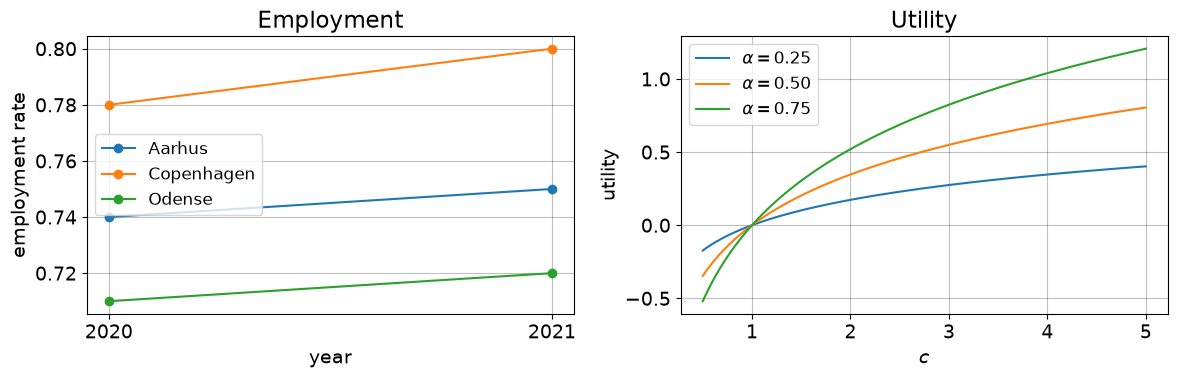

In [47]:
fig,axs = plt.subplots(1,2,figsize=(12,4))

# a. several lines from data
for name,d in df.groupby('municipality'):
    axs[0].plot(d.year,d.emp,'-o',label=name)

axs[0].set(xlabel='year',ylabel='employment rate',title='Employment')
axs[0].set_xticks([2020,2021])
axs[0].legend(frameon=True,fontsize=12)

# b. several lines from a function
c = np.linspace(0.5,5,100)
for alpha_ in [0.25,0.50,0.75]:
    axs[1].plot(c,alpha_*np.log(c),label=rf'$\alpha = {alpha_:.2f}$')

axs[1].set(xlabel='$c$',ylabel='utility',title='Utility')
axs[1].legend(frameon=True,fontsize=12)

fig.tight_layout()
# fig.savefig('utility.pdf') # save it when you need it in a document

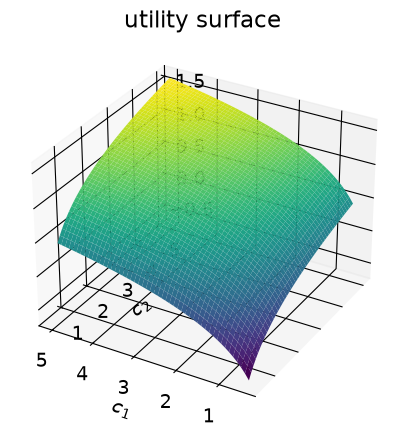

In [48]:
c1 = np.linspace(0.5,5,50)
c2 = np.linspace(0.5,5,50)
C1,C2 = np.meshgrid(c1,c2,indexing='ij') # broadcasting again
U = 0.5*np.log(C1)+0.5*np.log(C2)

fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(1,1,1,projection='3d')
ax.plot_surface(C1,C2,U,cmap='viridis')
ax.set(xlabel='$c_1$',ylabel='$c_2$',title='utility surface')
ax.invert_xaxis()

### 9.5. <a id='toc9_5_'></a>[Save and load](#toc0_)

In [49]:
# csv
df.to_csv('tmp.csv',index=False)
print(f'{pd.read_csv("tmp.csv").shape = }')

# pickle: anything python
with open('tmp.p','wb') as f: pickle.dump({'df':df,'alpha':alpha},f)
with open('tmp.p','rb') as f: data = pickle.load(f)
print(f'{list(data.keys()) = }')

# npz: numpy arrays
np.savez('tmp.npz',x=np.arange(5),y=np.ones((2,2)))
with np.load('tmp.npz') as d:
    print(f'{d["x"] = }')
    print(f'{d["y"].shape = }')

# plain text
with open('tmp.txt','w') as f: f.write(f'alpha = {alpha:.2f}\n')
with open('tmp.txt','r') as f: print(f.read(),end='')

for filename in ['tmp.csv','tmp.p','tmp.npz','tmp.txt']: os.remove(filename) # clean up

pd.read_csv("tmp.csv").shape = (6, 5)
list(data.keys()) = ['df', 'alpha']
d["x"] = array([0, 1, 2, 3, 4])
d["y"].shape = (2, 2)
alpha = 0.50


**Files and APIs.** Messy Excel files are read with `pd.read_excel(...,skiprows=...)` and then cleaned (rename, drop, convert types). Online data comes from an API - `dstapi` for Statistics Denmark and `fredapi` for FRED. They are not run here because they need internet, see [02_From_API.ipynb](../07_08_DescriptiveEconomics/02_From_API.ipynb) and [03_From_Excel.ipynb](../07_08_DescriptiveEconomics/03_From_Excel.ipynb).

## 10. <a id='toc10_'></a>[Solving and simulating a model](#toc0_)

*Lecture 9-10.* This is where everything above comes together.

* Parameters are **attributes**, equations and solvers are **methods**, results are collected in `self.sol` or `self.sim`.
* Solve **by hand and numerically** - the first is the test of the second.
* Write the methods with plain arithmetic, and the same code runs on one number and on a whole grid.
* Let an argument be **either a number or an array**, and one method covers the baseline, a policy change and random shocks.

In [50]:
class SolowModel:
    """ the Solow model: k_{t+1} = s*f(k_t) + (1-delta)*k_t """

    def __init__(self,alpha=0.30,s=0.20,delta=0.10):
        self.alpha = alpha
        self.s = s
        self.delta = delta
        self.sim = SimpleNamespace()

    def f(self,k):
        """ production function (works on a number and on an array) """

        return k**self.alpha

    def k_next(self,k,s):
        """ law of motion """

        return s*self.f(k)+(1-self.delta)*k

    def steady_state(self):
        """ analytical steady state """

        return (self.s/self.delta)**(1/(1-self.alpha))

    def solve_steady_state(self):
        """ numerical steady state """

        obj = lambda k: self.k_next(k,self.s)-k
        res = optimize.root_scalar(obj,bracket=[1e-4,100],method='brentq')

        return res.root

    def simulate(self,k0=0.1,T=100,N=1,s=None):
        """ simulate forward; s is a number, a path (T,1) or a panel (T,N) """

        s = self.s if s is None else s
        s = np.zeros((T,N))+s # broadcasting handles all three cases

        k = np.zeros((T,N))
        k[0,:] = k0
        for t in range(1,T): # loop over time, vectorized over economies
            k[t,:] = self.k_next(k[t-1,:],s[t-1,:])

        self.sim.k = k

        return k

**Test before you use it.** A case where you know the answer - and, better, a **property** that must hold whatever the answer turns out to be.

In [51]:
model = SolowModel()

kss_hand = model.steady_state()
kss_num = model.solve_steady_state()

print(f'{kss_hand = :.8f}')
print(f'{kss_num = :.8f}')

assert np.isclose(kss_hand,kss_num), 'the two steady states disagree'
assert np.isclose(model.k_next(kss_hand,model.s),kss_hand), 'the steady state is not a resting point'

k = model.simulate(k0=1.0,T=3,s=0.0) # known case: without saving, capital just decays
assert np.allclose(k[:,0],[1.0,0.9,0.81]), 'the decay is wrong'

print('all tests passed')

kss_hand = 2.69180039
kss_num = 2.69180039
all tests passed


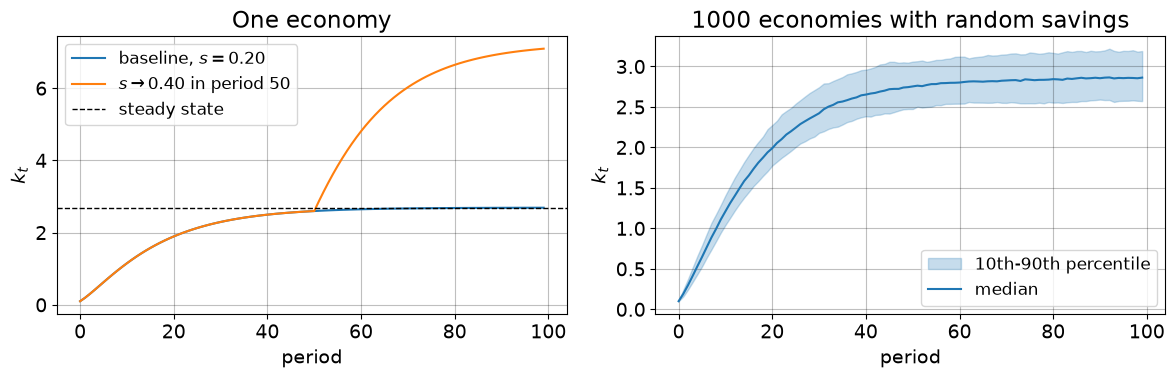

In [52]:
T = 100

k_base = model.simulate(k0=0.1,T=T)                   # s is a number

s_path = np.full((T,1),model.s); s_path[T//2:] = 0.40 # s is a path
k_policy = model.simulate(k0=0.1,T=T,s=s_path)

N = 1000                                              # s is a panel
rng = np.random.default_rng(1917)
s_panel = model.s*np.exp(rng.normal(scale=0.30,size=(T,N)))
k_random = model.simulate(k0=0.1,T=T,N=N,s=s_panel)

fig,axs = plt.subplots(1,2,figsize=(12,4))

axs[0].plot(k_base[:,0],label='baseline, $s = 0.20$')
axs[0].plot(k_policy[:,0],label=r'$s \rightarrow 0.40$ in period 50')
axs[0].axhline(kss_hand,ls='--',lw=1,color='black',label='steady state')
axs[0].set(xlabel='period',ylabel='$k_t$',title='One economy')
axs[0].legend(frameon=True,fontsize=12)

t = np.arange(T)
axs[1].fill_between(t,np.percentile(k_random,10,axis=1),np.percentile(k_random,90,axis=1),
                    alpha=0.25,color=colors[0],label='10th-90th percentile')
axs[1].plot(t,np.percentile(k_random,50,axis=1),color=colors[0],label='median')
axs[1].set(xlabel='period',ylabel='$k_t$',title=f'{N} economies with random savings')
axs[1].legend(frameon=True,fontsize=12)

fig.tight_layout()

Three different experiments, **one** `simulate` method - and a distribution instead of a single number.

## 11. <a id='toc11_'></a>[Structure, testing, debugging and Git](#toc0_)

*Lecture 8. Mostly words - but this is what the projects are about.*

**Structure.** One folder, one file that runs it all. Long functions and classes go in `.py` modules, and the notebook imports them and calls them (with `%autoreload 2` so edits take effect without a restart). Small functions, few repeated lines, no unexpected side effects. A consistent style: e.g. 4-space indentation, `CamelCase` for classes, `lower_case` for functions and variables, ordered section comments.

**Documentation.** Line comments explain *why*, docstrings explain what goes in and what comes out.

**Testing.** `assert` on cases where you already know the answer - and better, on a **property** that must hold whatever the answer is: the budget binds, the market clears, the shares sum to one, the steady state does not move. When you write your own algorithm, **return whether it converged** - and check it.

**Debugging.** Read the traceback **from the bottom**. Print shapes and values just before the line that fails. The classics: a global you forgot about (scope), `t` instead of `t-1` (index), a view you thought was a copy - and `nan`, which spreads silently instead of raising an error.

In [53]:
x = np.array([1.0,-1.0,2.0])
u = np.log(x)           # RuntimeWarning: invalid value - not an error!

print(f'{u = }')
print(f'{u.mean() = }') # the nan has spread to everything

u = array([0.        ,        nan, 0.69314718])
u.mean() = np.float64(nan)


C:\Users\gmf123\AppData\Local\Temp\ipykernel_3692\1933238732.py:2: RuntimeWarning: invalid value encountered in log
  u = np.log(x)           # RuntimeWarning: invalid value - not an error!


**Git** *(not required material)*. A **local** repository on your computer, a **remote** one on GitHub, and `.gitignore` for files that should not be tracked. *Fetch/pull* before you start, *stage* and *commit* (with a message that says what changed), then *push*. Sync often - that is what prevents most merge conflicts. A conflict is resolved by deciding, line by line, what the file should look like.

## 12. <a id='toc12_'></a>[Before you hand in](#toc0_)

The competencies from the checklist, as a list to run through:

1. **Restart kernel and run all cells.** Top to bottom, no errors, no cells that only work in a special order. It must run on **another person's computer**: relative paths, data included, no hidden files.
2. **The notebook reads as a report.** Every result is introduced, explained and interpreted in words. Nobody should have to guess why a cell is there.
3. **Figures and tables stand on their own** - labels, units, title, legend.
4. **The right tool for the question:** optimizer, root-finder, simulation or pandas? And **sanity-check the answer**: the sign, the order of magnitude, and a limit case you know by hand.

## 13. <a id='toc13_'></a>[Where to look it up](#toc0_)

| topic | notebooks |
| --- | --- |
| computers, types, containers, loops, functions, floats | [02_Python_Basics](../02_Python_Basics/) |
| classes, numpy, views vs. copies | [03_Classes_and_Numpy](../03_Classes_and_Numpy/) |
| printing and plotting | [04_Printing_and_Plotting](../04_Printing_and_Plotting/) |
| optimizers and root-finders | [05_Optimization_and_RootFinding](../05_Optimization_and_RootFinding/) |
| random numbers, save and load | [06_RandomNumbers](../06_RandomNumbers/Random_Numbers.ipynb) |
| pandas, APIs, Excel, groupby, merge | [07_08_DescriptiveEconomics](../07_08_DescriptiveEconomics/) |
| structure, debugging, git | [08_DataProject](../08_DataProject/) |
| a model from equations to figures | [Solow](../09_Solow_model/Solow_model.ipynb), [Walras](../10_Walras/ExchangeEconomy.ipynb) |